In [1]:
import torch
import gc
import random
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from datasets import load_dataset
from datasets import Dataset

import torch.nn.functional as F
from torch.utils.data import DataLoader

from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM
)
from transformers import AutoConfig


c:\Users\Usuario\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
device = (
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print(device)

cuda


In [3]:
dataset = load_dataset("wangrongsheng/ag_news")

In [4]:
MODEL_NAME = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"
MAX_MODEL_LENGTH = 2048
MAX_LENGTH = 2048

In [5]:
label_token_dict = {
    0: "World",
    1: "Sports",
    2: "Business",
    3: "Science"
}


def build_prompt(text):

    prompt = f"""Article: {text}

Theme:"""

    return prompt


def build_full_text(text, label):

    theme = label_token_dict[label]

    full_text = f"""Article: {text}

Theme: {theme}"""

    return full_text


def preprocess_dataset(dataset, tokenizer):
    records = dataset.to_dict("records")

    reviews    = [r["text"]  for r in records]
    raw_labels = [r["label"] for r in records]

    full_texts   = [build_full_text(rev, lbl) for rev, lbl in zip(reviews, raw_labels)]
    prompt_texts = [build_prompt(rev) for rev in reviews]

    full_enc = tokenizer(
        full_texts,
        add_special_tokens=False,
        max_length=MAX_LENGTH,
        padding="max_length",
        truncation=True,
    )
    prompt_enc = tokenizer(
        prompt_texts,
        add_special_tokens=False,
    )

    labels_list = [
        [
            -100 if (i < len(prompt_ids) or attn == 0) else tok
            for i, (tok, attn) in enumerate(zip(input_ids, attention_mask))
        ]
        for input_ids, attention_mask, prompt_ids in zip(
            full_enc["input_ids"],
            full_enc["attention_mask"],
            prompt_enc["input_ids"],
        )
    ]

    true_labels_list = [label_token_dict[l] for l in raw_labels]

    return Dataset.from_dict({
        "input_ids":      full_enc["input_ids"],
        "attention_mask": full_enc["attention_mask"],
        "labels":         labels_list,
        "true_label":     true_labels_list,
        "texts":          reviews,
    })


In [6]:
# Model tokenizer
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

In [9]:
def fits_model(example):

    text = build_full_text(
        example["text"],
        example["label"]
    )

    tokens = tokenizer(
        text,
        add_special_tokens=False
    )["input_ids"]

    return len(tokens) <= MAX_MODEL_LENGTH

In [12]:
import pandas as pd
import random

BATCH_SIZE      = 1
N_PER_CLASS     = 50  # 50 x 4 classes = 200 total
AGNEWS_CLASSES  = ["World", "Sports", "Business", "Science"]

test_raw      = pd.DataFrame(dataset["test"])
filtered_test = test_raw[test_raw.apply(fits_model, axis=1)].reset_index(drop=True)
test_dataset  = preprocess_dataset(filtered_test, tokenizer)

random.seed(42)
eval_idx = []
for lbl in AGNEWS_CLASSES:
    idx = [i for i in range(len(test_dataset)) if test_dataset[i]["true_label"] == lbl]
    eval_idx.extend(random.sample(idx, N_PER_CLASS))

test_subset = test_dataset.select(eval_idx)
test_subset.set_format(type="torch", columns=["input_ids", "attention_mask", "labels", "true_label", "texts"])
test_loader = DataLoader(test_subset, batch_size=BATCH_SIZE, shuffle=False)

eval_texts  = [test_subset[i]["texts"]      for i in range(len(test_subset))]
eval_labels = [test_subset[i]["true_label"] for i in range(len(test_subset))]
print(f"Eval: {len(eval_idx)} examples | "
      + ", ".join(f"{l}: {eval_labels.count(l)}" for l in AGNEWS_CLASSES))


Eval: 200 examples | World: 50, Sports: 50, Business: 50, Science: 50


In [13]:
CHECKPOINT_DIR = "../checkpoints/agnews"

config_11 = AutoConfig.from_pretrained(MODEL_NAME, local_files_only=True)
config_11.num_hidden_layers = 11


def load_model(n_layers, ckpt_name):
    if n_layers == 22:
        m = AutoModelForCausalLM.from_pretrained(
            MODEL_NAME, local_files_only=True, attn_implementation="eager"
        )
    else:
        m = AutoModelForCausalLM.from_config(config_11, attn_implementation="eager")
    m.load_state_dict(torch.load(f"{CHECKPOINT_DIR}/{ckpt_name}", map_location="cpu"))
    m.eval()
    return m


MODELS = {
    "teacher":       load_model(22, "best_teacher_model.pt"),
    "baseline":      load_model(11, "best_baseline_model.pt"),
    "bad_student":   load_model(11, "best_bad_student_model.pt"),
    "student":       load_model(11, "best_student_model.pt"),
    "student_local": load_model(11, "best_student_local_model.pt"),
}
MODEL_LABELS = {
    "teacher":       "P (teacher)",
    "baseline":      "B (no KD)",
    "bad_student":   "S_bad",
    "student":       "S1",
    "student_local": "S2",
}
print("Loaded:", list(MODELS.keys()))


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 2936.52it/s]


Loaded: ['teacher', 'baseline', 'bad_student', 'student', 'student_local']


# Métricas de comparación

In [14]:
def frobenius_difference(
    x: torch.Tensor,
    y: torch.Tensor
):
    return torch.norm(
        x - y,
        p="fro"
    )


def cosine_similarity_tensor(
    x: torch.Tensor,
    y: torch.Tensor,
    eps: float = 1e-8
):
    x_flat = x.reshape(-1)
    y_flat = y.reshape(-1)

    similarity = F.cosine_similarity(
        x_flat.unsqueeze(0),
        y_flat.unsqueeze(0),
        dim=1,
        eps=eps
    )

    return similarity.squeeze()

def js_divergence_attention(
    attn_teacher: torch.Tensor,
    attn_student: torch.Tensor,
    eps: float = 1e-8
):
    # normalizar filas
    p = attn_teacher / (
        attn_teacher.sum(dim=-1, keepdim=True)
        + eps
    )

    q = attn_student / (
        attn_student.sum(dim=-1, keepdim=True)
        + eps
    )

    m = 0.5 * (p + q)

    kl_pm = torch.sum(
        p * torch.log(
            (p + eps) / (m + eps)
        ),
        dim=-1
    )

    kl_qm = torch.sum(
        q * torch.log(
            (q + eps) / (m + eps)
        ),
        dim=-1
    )

    jsd_rows = 0.5 * (
        kl_pm + kl_qm
    )

    return jsd_rows.mean()

def linear_cka(X, Y):
    """Linear CKA between activation matrices X:[n,d1] and Y:[n,d2]."""
    X = X.float();  Y = Y.float()
    n = X.shape[0]
    X = X - X.mean(0, keepdim=True)
    Y = Y - Y.mean(0, keepdim=True)
    K = X @ X.T;  L = Y @ Y.T
    H = torch.eye(n, device=X.device) - torch.ones(n, n, device=X.device) / n
    Kc = H @ K @ H;  Lc = H @ L @ H
    hsic_kl = (Kc * Lc).sum()
    hsic_kk = (Kc * Kc).sum()
    hsic_ll = (Lc * Lc).sum()
    return (hsic_kl / (torch.sqrt(hsic_kk * hsic_ll) + 1e-10)).item()


# Rango efectivo

In [15]:
def effective_rank_participation_ratio(
    x: torch.Tensor,
    eps: float = 1e-12
):

    x = x.float()

    singular_values = (
        torch.linalg.svdvals(x)
    )

    power = singular_values**2

    numerator = (
        power.sum()**2
    )

    denominator = (
        (power**2).sum()
        + eps
    )

    rank_eff = (
        numerator
        / denominator
    )

    return rank_eff


def effective_rank_entropy(
    x: torch.Tensor,
    eps: float = 1e-12
):

    x = x.float()

    singular_values = (
        torch.linalg.svdvals(x)
    )

    p = singular_values / (
        singular_values.sum()
        + eps
    )

    entropy = -torch.sum(
        p * torch.log(p + eps)
    )

    rank_eff = torch.exp(entropy)

    return rank_eff

# Atención promedio

In [16]:
def compute_average_attentions(
    model,
    dataloader,
    device,
    max_batches=None,
    print_every=50
):

    model.eval()

    n_layers = (
        model.config.num_hidden_layers
    )

    attention_sums = [

        torch.zeros(
            (2048, 2048),
            dtype=torch.float32,
            device="cpu"
        )

        for _ in range(n_layers)
    ]

    n_examples = 0

    with torch.no_grad():

        for batch_idx, batch in enumerate(
            dataloader
        ):

            if (
                max_batches is not None
                and batch_idx >= max_batches
            ):
                break

            input_ids = batch[
                "input_ids"
            ].to(device)

            attention_mask = batch[
                "attention_mask"
            ].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                output_attentions=True
            )

            attentions = (
                outputs.attentions
            )

            batch_size = (
                input_ids.size(0)
            )

            for layer_idx in range(
                n_layers
            ):

                attn = attentions[
                    layer_idx
                ]

                # (B, H, S, S)
                # promedio heads
                attn = attn.mean(
                    dim=1
                )

                # (B, S, S)
                attn = (
                    attn
                    .float()
                    .cpu()
                )

                # suma batch
                attn_sum = attn.sum(
                    dim=0
                )

                attention_sums[
                    layer_idx
                ] += attn_sum

            n_examples += batch_size

            if (
                batch_idx
                % print_every
                == 0
            ):

                print(
                    f"Batch "
                    f"{batch_idx} | "
                    f"Examples "
                    f"{n_examples}"
                )

            del (
                input_ids,
                attention_mask,
                outputs,
                attentions,
                attn
            )

            gc.collect()

            torch.cuda.empty_cache()

    attention_means = [

        attn_sum / n_examples

        for attn_sum
        in attention_sums
    ]

    return attention_means

In [17]:
def compute_hidden_states(model, prompts, tokenizer, device, n=100, max_seq=512):
    """
    Returns [n_layers+1, n, hidden_dim] – last real-token hidden vector per layer.
    """
    model.eval()
    all_hidden = []
    with torch.no_grad():
        for prompt in prompts[:n]:
            enc = tokenizer(prompt, return_tensors="pt", truncation=True,
                            max_length=max_seq, add_special_tokens=False)
            input_ids = enc["input_ids"].to(device)
            attn_mask = enc["attention_mask"].to(device)
            last_idx  = int(attn_mask[0].nonzero()[-1].item())
            out = model(input_ids=input_ids, attention_mask=attn_mask,
                        output_hidden_states=True)
            hidden = torch.stack(
                [h[0, last_idx, :] for h in out.hidden_states]
            ).cpu()  # [n_layers+1, hidden_dim]
            all_hidden.append(hidden)
            del out;  torch.cuda.empty_cache()
    return torch.stack(all_hidden, dim=1)  # [n_layers+1, n, hidden_dim]


def compute_head_avg_patterns(model, prompts, tokenizer, device, n=50, max_seq=128):
    """
    Returns [n_layers, n_heads, max_seq] – avg attention from last token per head.
    """
    model.eval()
    n_layers = model.config.num_hidden_layers
    n_heads  = model.config.num_attention_heads
    sums  = torch.zeros(n_layers, n_heads, max_seq, dtype=torch.float32)
    count = 0
    with torch.no_grad():
        for prompt in prompts[:n]:
            enc = tokenizer(prompt, return_tensors="pt", truncation=True,
                            max_length=max_seq, add_special_tokens=False)
            input_ids = enc["input_ids"].to(device)
            attn_mask = enc["attention_mask"].to(device)
            seq_len   = input_ids.size(1)
            last_idx  = int(attn_mask[0].nonzero()[-1].item())
            out = model(input_ids=input_ids, attention_mask=attn_mask,
                        output_attentions=True)
            for l in range(n_layers):
                # [1, n_heads, S, S] -> [n_heads, seq_len]
                ha = out.attentions[l][0, :, last_idx, :seq_len].float().cpu()
                padded = torch.zeros(n_heads, max_seq)
                padded[:, :seq_len] = ha
                sums[l] += padded
            count += 1
            del out;  torch.cuda.empty_cache()
    return sums / count  # [n_layers, n_heads, max_seq]


## Teacher

In [18]:
# Central attention computation for all 5 models
model_attentions = {}
for name, model in MODELS.items():
    print(f"Computing attentions for {MODEL_LABELS[name]}...")
    model.to(device)
    model_attentions[name] = compute_average_attentions(model, test_loader, device)
    model.cpu()
    torch.cuda.empty_cache()
    gc.collect()

# 22-layer teacher attentions (needed by teacher_avg_attentions + teacher_rollouts)
teacher_attentions = model_attentions["teacher"]

# Aliases — existing pairwise comparison cells use these names unchanged
baseline_attentions      = model_attentions["baseline"]
bad_student_attentions   = model_attentions["bad_student"]
student_attentions       = model_attentions["student"]
student_local_attentions = model_attentions["student_local"]

print("All attention maps computed.")


Computing attentions for P (teacher)...
Batch 0 | Examples 1
Batch 50 | Examples 51
Batch 100 | Examples 101
Batch 150 | Examples 151
Computing attentions for B (no KD)...
Batch 0 | Examples 1
Batch 50 | Examples 51
Batch 100 | Examples 101
Batch 150 | Examples 151
Computing attentions for S_bad...
Batch 0 | Examples 1
Batch 50 | Examples 51
Batch 100 | Examples 101
Batch 150 | Examples 151
Computing attentions for S1...
Batch 0 | Examples 1
Batch 50 | Examples 51
Batch 100 | Examples 101
Batch 150 | Examples 151
Computing attentions for S2...
Batch 0 | Examples 1
Batch 50 | Examples 51
Batch 100 | Examples 101
Batch 150 | Examples 151
All attention maps computed.


In [19]:
teacher_avg_attentions = [
    (teacher_attentions[2*i] + teacher_attentions[2*i + 1]) / 2
    for i in range(11)
]

In [20]:
def rollout_pair(A1, A2):
    I = torch.eye(A1.shape[-1], device=A1.device)
    
    # agregar residual y renormalizar
    A1 = A1 + I
    A1 = A1 / A1.sum(dim=-1, keepdim=True)
    
    A2 = A2 + I
    A2 = A2 / A2.sum(dim=-1, keepdim=True)
    
    return A1 @ A2

teacher_rollouts = [rollout_pair(teacher_attentions[2*i], teacher_attentions[2*i+1]) for i in range(11)]

# Teacher - Baseline comparison

In [21]:
# Cosine similarity entre attention maps
print("Similitud coseno con promedio de atenciones")
for i, (battn, tattn) in enumerate(zip(baseline_attentions, teacher_avg_attentions)):
    print(cosine_similarity_tensor(battn, tattn))

print("\n")

print("Similitud coseno con Attention Rollout")
for i, (battn, tattn) in enumerate(zip(baseline_attentions, teacher_rollouts)):
    print(cosine_similarity_tensor(battn, tattn))

Similitud coseno con promedio de atenciones
tensor(0.9809)
tensor(0.3683)
tensor(0.4252)
tensor(0.4354)
tensor(0.5175)
tensor(0.3318)
tensor(0.2992)
tensor(0.2722)
tensor(0.4182)
tensor(0.2517)
tensor(0.3111)


Similitud coseno con Attention Rollout
tensor(0.3604)
tensor(0.2943)
tensor(0.4023)
tensor(0.4116)
tensor(0.4464)
tensor(0.2772)
tensor(0.2373)
tensor(0.2141)
tensor(0.3387)
tensor(0.1986)
tensor(0.2533)


In [22]:
# Frobenius distance entre attention maps
print("Distancia Frobenius con promedio de atenciones")
for i, (battn, tattn) in enumerate(zip(baseline_attentions, teacher_avg_attentions)):
    print(frobenius_difference(battn, tattn))

print("\n")

print("Distancia Frobenius con Attention Rollout")
for i, (battn, tattn) in enumerate(zip(baseline_attentions, teacher_rollouts)):
    print(frobenius_difference(battn, tattn))

Distancia Frobenius con promedio de atenciones
tensor(1.0771)
tensor(19.9431)
tensor(39.2226)
tensor(37.7779)
tensor(21.4166)
tensor(21.2386)
tensor(18.2787)
tensor(18.0496)
tensor(17.3306)
tensor(19.0009)
tensor(19.3262)


Distancia Frobenius con Attention Rollout
tensor(11.4296)
tensor(22.2094)
tensor(31.8605)
tensor(31.0443)
tensor(22.2048)
tensor(22.5280)
tensor(20.5030)
tensor(20.5502)
tensor(20.1117)
tensor(21.4719)
tensor(21.2312)


In [23]:
# JS local
print("JS promediada por fila con promedio de atenciones")
for i, (battn, tattn) in enumerate(zip(baseline_attentions, teacher_avg_attentions)):
    print(js_divergence_attention(battn, tattn))

print("\n")

print("JS promediada por fila con Attention Rollout")
for i, (battn, tattn) in enumerate(zip(baseline_attentions, teacher_rollouts)):
    print(js_divergence_attention(battn, tattn))

JS promediada por fila con promedio de atenciones
tensor(0.0051)
tensor(0.1724)
tensor(0.4495)
tensor(0.4159)
tensor(0.2499)
tensor(0.2960)
tensor(0.2725)
tensor(0.3123)
tensor(0.2844)
tensor(0.3413)
tensor(0.3002)


JS promediada por fila con Attention Rollout
tensor(0.1001)
tensor(0.2985)
tensor(0.5056)
tensor(0.4801)
tensor(0.3381)
tensor(0.3731)
tensor(0.3434)
tensor(0.3745)
tensor(0.3532)
tensor(0.4049)
tensor(0.3671)


In [24]:
# Participation ratio
print("Participation ratio")
print("index | student | teacher_avg | teacher_rollout")
print("-----------------------------------------------")
for i, (battn, tattn, tattn2) in enumerate(zip(baseline_attentions, teacher_avg_attentions, teacher_rollouts)):
    print(f"{i} | {effective_rank_participation_ratio(battn):4f} | {effective_rank_participation_ratio(tattn):4f} | {effective_rank_participation_ratio(tattn2):4f}")

Participation ratio
index | student | teacher_avg | teacher_rollout
-----------------------------------------------
0 | 1.285303 | 1.368376 | 69.870155
1 | 1.613763 | 1.005685 | 1.727273
2 | 1.604629 | 1.000083 | 1.265424
3 | 1.895964 | 1.000215 | 1.278281
4 | 1.852749 | 1.006090 | 1.621009
5 | 2.664674 | 1.003180 | 1.703296
6 | 2.401048 | 1.006765 | 1.990709
7 | 3.380600 | 1.008512 | 2.023562
8 | 2.596471 | 1.008427 | 1.941696
9 | 4.321425 | 1.007967 | 1.904512
10 | 3.253539 | 1.007418 | 1.882577


In [25]:
# Entropy based effective rank
print("Entropy based effective rank")
print("index | student | teacher_avg | teacher_rollout")
print("-----------------------------------------------")
for i, (battn, tattn, tattn2) in enumerate(zip(baseline_attentions, teacher_avg_attentions, teacher_rollouts)):
    print(f"{i} | {effective_rank_entropy(battn):4f} | {effective_rank_entropy(tattn):4f} | {effective_rank_entropy(tattn2):4f}")

Entropy based effective rank
index | student | teacher_avg | teacher_rollout
-----------------------------------------------
0 | 12.734205 | 23.991528 | 2010.585327
1 | 32.673119 | 4.314828 | 1799.319702
2 | 29.041311 | 1.373658 | 1633.887451
3 | 39.987854 | 1.638819 | 1643.481323
4 | 42.439640 | 2.821766 | 1778.275635
5 | 52.122482 | 2.777171 | 1795.786621
6 | 58.879101 | 4.338955 | 1835.872314
7 | 61.794956 | 5.050489 | 1839.056274
8 | 61.551338 | 4.511696 | 1830.135986
9 | 61.560410 | 3.782088 | 1825.746460
10 | 66.314613 | 6.464252 | 1822.294312


# Teacher - Bad Student comparison

In [26]:
# Cosine similarity entre attention maps
print("Similitud coseno con promedio de atenciones")
for i, (bsattn, tattn) in enumerate(zip(bad_student_attentions, teacher_avg_attentions)):
    print(cosine_similarity_tensor(bsattn, tattn))

print("\n")

print("Similitud coseno con Attention Rollout")
for i, (bsattn, tattn) in enumerate(zip(bad_student_attentions, teacher_rollouts)):
    print(cosine_similarity_tensor(bsattn, tattn))

Similitud coseno con promedio de atenciones
tensor(0.9648)
tensor(0.6935)
tensor(0.3180)
tensor(0.3881)
tensor(0.3454)
tensor(0.3981)
tensor(0.3415)
tensor(0.3428)
tensor(0.2777)
tensor(0.3962)
tensor(0.2778)


Similitud coseno con Attention Rollout
tensor(0.3646)
tensor(0.5823)
tensor(0.3032)
tensor(0.3701)
tensor(0.2968)
tensor(0.3368)
tensor(0.2732)
tensor(0.2701)
tensor(0.2152)
tensor(0.3161)
tensor(0.2137)


In [27]:
# Frobenius distance entre attention maps
print("Distancia Frobenius con promedio de atenciones")
for i, (bsattn, tattn) in enumerate(zip(bad_student_attentions, teacher_avg_attentions)):
    print(frobenius_difference(bsattn, tattn))

print("\n")

print("Distancia Frobenius con Attention Rollout")
for i, (bsattn, tattn) in enumerate(zip(bad_student_attentions, teacher_rollouts)):
    print(frobenius_difference(bsattn, tattn))

Distancia Frobenius con promedio de atenciones
tensor(1.4618)
tensor(17.2232)
tensor(40.1567)
tensor(38.5100)
tensor(22.9589)
tensor(20.9162)
tensor(18.0080)
tensor(17.5153)
tensor(18.3096)
tensor(17.9335)
tensor(19.5172)


Distancia Frobenius con Attention Rollout
tensor(11.4073)
tensor(19.9449)
tensor(32.6890)
tensor(31.6491)
tensor(23.4497)
tensor(22.1841)
tensor(20.2386)
tensor(20.0769)
tensor(20.9055)
tensor(20.5497)
tensor(21.4074)


In [28]:
# JS local
print("JS promediada por fila con promedio de atenciones")
for i, (bsattn, tattn) in enumerate(zip(bad_student_attentions, teacher_avg_attentions)):
    print(js_divergence_attention(bsattn, tattn))

print("\n")

print("JS promediada por fila con Attention Rollout")
for i, (bsattn, tattn) in enumerate(zip(bad_student_attentions, teacher_rollouts)):
    print(js_divergence_attention(bsattn, tattn))

JS promediada por fila con promedio de atenciones
tensor(0.0066)
tensor(0.1075)
tensor(0.4789)
tensor(0.4313)
tensor(0.2303)
tensor(0.2270)
tensor(0.2188)
tensor(0.2292)
tensor(0.2612)
tensor(0.2443)
tensor(0.2373)


JS promediada por fila con Attention Rollout
tensor(0.1005)
tensor(0.2381)
tensor(0.5339)
tensor(0.4971)
tensor(0.3363)
tensor(0.3235)
tensor(0.3037)
tensor(0.3116)
tensor(0.3435)
tensor(0.3284)
tensor(0.3289)


In [29]:
# Participation ratio
print("Participation ratio")
print("index | student | teacher_avg | teacher_rollout")
print("-----------------------------------------------")
for i, (bsattn, tattn, tattn2) in enumerate(zip(bad_student_attentions, teacher_avg_attentions, teacher_rollouts)):
    print(f"{i} | {effective_rank_participation_ratio(bsattn):4f} | {effective_rank_participation_ratio(tattn):4f} | {effective_rank_participation_ratio(tattn2):4f}")

Participation ratio
index | student | teacher_avg | teacher_rollout
-----------------------------------------------
0 | 1.302765 | 1.368376 | 69.870155
1 | 1.320030 | 1.005685 | 1.727273
2 | 1.435312 | 1.000083 | 1.265424
3 | 1.370121 | 1.000215 | 1.278281
4 | 1.370707 | 1.006090 | 1.621009
5 | 1.408825 | 1.003180 | 1.703296
6 | 1.470336 | 1.006765 | 1.990709
7 | 1.534465 | 1.008512 | 2.023562
8 | 1.480240 | 1.008427 | 1.941696
9 | 1.445793 | 1.007967 | 1.904512
10 | 1.556530 | 1.007418 | 1.882577


In [30]:
# Entropy based effective rank
print("Entropy based effective rank")
print("index | student | teacher_avg | teacher_rollout")
print("-----------------------------------------------")
for i, (bsattn, tattn, tattn2) in enumerate(zip(bad_student_attentions, teacher_avg_attentions, teacher_rollouts)):
    print(f"{i} | {effective_rank_entropy(bsattn):4f} | {effective_rank_entropy(tattn):4f} | {effective_rank_entropy(tattn2):4f}")

Entropy based effective rank
index | student | teacher_avg | teacher_rollout
-----------------------------------------------
0 | 13.922149 | 23.991528 | 2010.585327
1 | 14.896980 | 4.314828 | 1799.319702
2 | 13.521515 | 1.373658 | 1633.887451
3 | 18.959532 | 1.638819 | 1643.481323
4 | 19.937937 | 2.821766 | 1778.275635
5 | 23.804865 | 2.777171 | 1795.786621
6 | 31.121500 | 4.338955 | 1835.872314
7 | 31.810675 | 5.050489 | 1839.056274
8 | 30.721846 | 4.511696 | 1830.135986
9 | 30.279011 | 3.782088 | 1825.746460
10 | 27.840157 | 6.464252 | 1822.294312


## Teacher - Student comparison

In [31]:
# Cosine similarity entre attention maps
print("Similitud coseno con promedio de atenciones")
for i, (sattn, tattn) in enumerate(zip(student_attentions, teacher_avg_attentions)):
    print(cosine_similarity_tensor(sattn, tattn))

print("\n")

print("Similitud coseno con Attention Rollout")
for i, (sattn, tattn) in enumerate(zip(student_attentions, teacher_rollouts)):
    print(cosine_similarity_tensor(sattn, tattn))

Similitud coseno con promedio de atenciones
tensor(0.9679)
tensor(0.3014)
tensor(0.2305)
tensor(0.2217)
tensor(0.2904)
tensor(0.2800)
tensor(0.3367)
tensor(0.3333)
tensor(0.2723)
tensor(0.3168)
tensor(0.2262)


Similitud coseno con Attention Rollout
tensor(0.3621)
tensor(0.2348)
tensor(0.2279)
tensor(0.2193)
tensor(0.2621)
tensor(0.2394)
tensor(0.2802)
tensor(0.2673)
tensor(0.2139)
tensor(0.2581)
tensor(0.1813)


In [32]:
# Frobenius distance entre attention maps
print("Distancia Frobenius con promedio de atenciones")
for i, (sattn, tattn) in enumerate(zip(student_attentions, teacher_avg_attentions)):
    print(frobenius_difference(sattn, tattn))

print("\n")

print("Distancia Frobenius con Attention Rollout")
for i, (sattn, tattn) in enumerate(zip(student_attentions, teacher_rollouts)):
    print(frobenius_difference(sattn, tattn))

Distancia Frobenius con promedio de atenciones
tensor(1.3891)
tensor(20.3883)
tensor(40.6441)
tensor(39.4793)
tensor(23.2627)
tensor(21.6180)
tensor(18.0257)
tensor(17.5710)
tensor(18.3381)
tensor(18.4177)
tensor(19.8217)


Distancia Frobenius con Attention Rollout
tensor(11.4182)
tensor(22.5838)
tensor(33.1169)
tensor(32.5414)
tensor(23.6411)
tensor(22.7572)
tensor(20.1958)
tensor(20.0938)
tensor(20.9060)
tensor(20.8969)
tensor(21.5921)


In [33]:
# JS local
print("JS promediada por fila con promedio de atenciones")
for i, (sattn, tattn) in enumerate(zip(student_attentions, teacher_avg_attentions)):
    print(js_divergence_attention(sattn, tattn))

print("\n")

print("JS promediada por fila con Attention Rollout")
for i, (sattn, tattn) in enumerate(zip(student_attentions, teacher_rollouts)):
    print(js_divergence_attention(sattn, tattn))

JS promediada por fila con promedio de atenciones
tensor(0.0057)
tensor(0.1766)
tensor(0.5027)
tensor(0.4742)
tensor(0.2263)
tensor(0.2306)
tensor(0.2068)
tensor(0.2214)
tensor(0.2502)
tensor(0.2513)
tensor(0.2597)


JS promediada por fila con Attention Rollout
tensor(0.1025)
tensor(0.3090)
tensor(0.5528)
tensor(0.5342)
tensor(0.3348)
tensor(0.3328)
tensor(0.2948)
tensor(0.3061)
tensor(0.3377)
tensor(0.3360)
tensor(0.3442)


## Teacher - Student local comparison

In [34]:
# Cosine similarity entre attention maps
print("Similitud coseno con promedio de atenciones")
for i, (sattn, tattn) in enumerate(zip(student_local_attentions, teacher_avg_attentions)):
    print(cosine_similarity_tensor(sattn, tattn))

print("\n")

print("Similitud coseno con Attention Rollout")
for i, (sattn, tattn) in enumerate(zip(student_local_attentions, teacher_rollouts)):
    print(cosine_similarity_tensor(sattn, tattn))

Similitud coseno con promedio de atenciones
tensor(0.9748)
tensor(0.3689)
tensor(0.3674)
tensor(0.2284)
tensor(0.3445)
tensor(0.2970)
tensor(0.2977)
tensor(0.2775)
tensor(0.3127)
tensor(0.2929)
tensor(0.2640)


Similitud coseno con Attention Rollout
tensor(0.3613)
tensor(0.2966)
tensor(0.3625)
tensor(0.2330)
tensor(0.3222)
tensor(0.2677)
tensor(0.2583)
tensor(0.2258)
tensor(0.2479)
tensor(0.2482)
tensor(0.2181)


In [35]:
# Frobenius distance entre attention maps
print("Distancia Frobenius con promedio de atenciones")
for i, (sattn, tattn) in enumerate(zip(student_local_attentions, teacher_avg_attentions)):
    print(frobenius_difference(sattn, tattn))

print("\n")

print("Distancia Frobenius con Attention Rollout")
for i, (sattn, tattn) in enumerate(zip(student_local_attentions, teacher_rollouts)):
    print(frobenius_difference(sattn, tattn))

Distancia Frobenius con promedio de atenciones
tensor(1.2184)
tensor(19.9509)
tensor(39.6411)
tensor(39.4505)
tensor(22.9105)
tensor(21.5041)
tensor(18.2689)
tensor(17.9090)
tensor(18.0979)
tensor(18.5798)
tensor(19.6215)


Distancia Frobenius con Attention Rollout
tensor(11.4128)
tensor(22.1988)
tensor(32.1513)
tensor(32.4635)
tensor(23.2597)
tensor(22.5837)
tensor(20.3347)
tensor(20.3452)
tensor(20.7147)
tensor(20.9814)
tensor(21.4163)


In [36]:
# JS local
print("JS promediada por fila con promedio de atenciones")
for i, (sattn, tattn) in enumerate(zip(student_local_attentions, teacher_avg_attentions)):
    print(js_divergence_attention(sattn, tattn))

print("\n")

print("JS promediada por fila con Attention Rollout")
for i, (sattn, tattn) in enumerate(zip(student_local_attentions, teacher_rollouts)):
    print(js_divergence_attention(sattn, tattn))

JS promediada por fila con promedio de atenciones
tensor(0.0062)
tensor(0.1694)
tensor(0.4675)
tensor(0.4657)
tensor(0.2212)
tensor(0.2412)
tensor(0.2201)
tensor(0.2486)
tensor(0.2427)
tensor(0.2603)
tensor(0.2528)


JS promediada por fila con Attention Rollout
tensor(0.1057)
tensor(0.2996)
tensor(0.5190)
tensor(0.5247)
tensor(0.3252)
tensor(0.3343)
tensor(0.3034)
tensor(0.3264)
tensor(0.3287)
tensor(0.3403)
tensor(0.3354)


# Baseline - Student comparison

In [37]:
# Cosine similarity entre attention maps
print("Similitud coseno entre atenciones")
for i, (battn, sattn) in enumerate(zip(baseline_attentions, student_attentions)):
    print(cosine_similarity_tensor(battn, sattn))

Similitud coseno entre atenciones
tensor(0.9729)
tensor(0.7928)
tensor(0.7031)
tensor(0.6633)
tensor(0.6717)
tensor(0.6672)
tensor(0.7465)
tensor(0.6901)
tensor(0.7217)
tensor(0.6401)
tensor(0.6969)


In [38]:
# Frobenius distance entre attention maps
print("Distancia Frobenius entre atenciones")
for i, (battn, sattn) in enumerate(zip(baseline_attentions, student_attentions)):
    print(frobenius_difference(battn, sattn))

Distancia Frobenius entre atenciones
tensor(1.2861)
tensor(3.9026)
tensor(4.9546)
tensor(5.6421)
tensor(5.5053)
tensor(5.3804)
tensor(4.4963)
tensor(5.2511)
tensor(4.9164)
tensor(5.9896)
tensor(5.1803)


In [39]:
# JS local
print("JS promediada por fila entre atenciones")
for i, (battn, sattn) in enumerate(zip(baseline_attentions, student_attentions)):
    print(js_divergence_attention(battn, sattn))

JS promediada por fila entre atenciones
tensor(0.0062)
tensor(0.0630)
tensor(0.0950)
tensor(0.1060)
tensor(0.1010)
tensor(0.1128)
tensor(0.0765)
tensor(0.1040)
tensor(0.0963)
tensor(0.1322)
tensor(0.1016)


# Baseline - Student local comparison

In [40]:
# Cosine similarity entre attention maps
print("Similitud coseno entre atenciones")
for i, (battn, slattn) in enumerate(zip(baseline_attentions, student_local_attentions)):
    print(cosine_similarity_tensor(battn, slattn))

Similitud coseno entre atenciones
tensor(0.9796)
tensor(0.7708)
tensor(0.6660)
tensor(0.6519)
tensor(0.6989)
tensor(0.7015)
tensor(0.7298)
tensor(0.6982)
tensor(0.7225)
tensor(0.5905)
tensor(0.6668)


In [41]:
# Frobenius distance entre attention maps
print("Distancia Frobenius entre atenciones")
for i, (battn, slattn) in enumerate(zip(baseline_attentions, student_local_attentions)):
    print(frobenius_difference(battn, slattn))

Distancia Frobenius entre atenciones
tensor(1.1135)
tensor(4.1518)
tensor(5.4827)
tensor(5.6932)
tensor(5.3236)
tensor(5.1741)
tensor(4.7029)
tensor(5.2104)
tensor(4.9436)
tensor(6.5170)
tensor(5.5630)


In [42]:
# JS local
print("JS promediada por fila entre atenciones")
for i, (battn, slattn) in enumerate(zip(baseline_attentions, student_local_attentions)):
    print(js_divergence_attention(battn, slattn))


JS promediada por fila entre atenciones
tensor(0.0071)
tensor(0.0707)
tensor(0.0870)
tensor(0.0956)
tensor(0.0836)
tensor(0.0888)
tensor(0.0752)
tensor(0.1033)
tensor(0.0942)
tensor(0.1386)
tensor(0.1005)


# Baseline - Bad Student comparison

In [43]:
# Cosine similarity entre attention maps
print("Similitud coseno entre atenciones")
for i, (battn, bsattn) in enumerate(zip(baseline_attentions, bad_student_attentions)):
    print(cosine_similarity_tensor(battn, bsattn))

Similitud coseno entre atenciones
tensor(0.9719)
tensor(0.7342)
tensor(0.8374)
tensor(0.8098)
tensor(0.7993)
tensor(0.7646)
tensor(0.8083)
tensor(0.7228)
tensor(0.7383)
tensor(0.6656)
tensor(0.6688)


In [44]:
# Frobenius distance entre attention maps
print("Distancia Frobenius entre atenciones")
for i, (battn, bsattn) in enumerate(zip(baseline_attentions, bad_student_attentions)):
    print(frobenius_difference(battn, bsattn))

Distancia Frobenius entre atenciones
tensor(1.3130)
tensor(4.9251)
tensor(3.6789)
tensor(4.3010)
tensor(4.4274)
tensor(4.5834)
tensor(3.9115)
tensor(4.9878)
tensor(4.7931)
tensor(5.7878)
tensor(5.4120)


In [45]:
# JS local
print("JS promediada por fila entre atenciones")
for i, (battn, bsattn) in enumerate(zip(baseline_attentions, bad_student_attentions)):
    print(js_divergence_attention(battn, bsattn))

JS promediada por fila entre atenciones
tensor(0.0060)
tensor(0.0536)
tensor(0.0445)
tensor(0.0592)
tensor(0.0670)
tensor(0.0801)
tensor(0.0632)
tensor(0.0982)
tensor(0.0885)
tensor(0.1295)
tensor(0.1129)


# Bad Student - Student comparison

In [46]:
# Cosine similarity entre attention maps
print("Similitud coseno entre atenciones")
for i, (bsattn, sattn) in enumerate(zip(bad_student_attentions, student_attentions)):
    print(cosine_similarity_tensor(bsattn, sattn))

Similitud coseno entre atenciones
tensor(0.9824)
tensor(0.7979)
tensor(0.8981)
tensor(0.8977)
tensor(0.9089)
tensor(0.9044)
tensor(0.9421)
tensor(0.9342)
tensor(0.9120)
tensor(0.9153)
tensor(0.8707)


In [47]:
# Frobenius distance entre attention maps
print("Distancia Frobenius entre atenciones")
for i, (bsattn, sattn) in enumerate(zip(bad_student_attentions, student_attentions)):
    print(frobenius_difference(bsattn, sattn))

Distancia Frobenius entre atenciones
tensor(1.0392)
tensor(4.2922)
tensor(2.6663)
tensor(2.7385)
tensor(2.4256)
tensor(2.4818)
tensor(1.9511)
tensor(2.0543)
tensor(2.3947)
tensor(2.3738)
tensor(2.9305)


In [48]:
# JS local
print("JS promediada por fila entre atenciones")
for i, (bsattn, sattn) in enumerate(zip(bad_student_attentions, student_attentions)):
    print(js_divergence_attention(bsattn, sattn))

JS promediada por fila entre atenciones
tensor(0.0040)
tensor(0.0351)
tensor(0.0325)
tensor(0.0273)
tensor(0.0203)
tensor(0.0234)
tensor(0.0140)
tensor(0.0132)
tensor(0.0201)
tensor(0.0191)
tensor(0.0322)


# Bad Student - Student local comparison

In [49]:
# Cosine similarity entre attention maps
print("Similitud coseno entre atenciones")
for i, (bsattn, slattn) in enumerate(zip(bad_student_attentions, student_local_attentions)):
    print(cosine_similarity_tensor(bsattn, slattn))

Similitud coseno entre atenciones
tensor(0.9760)
tensor(0.8248)
tensor(0.8060)
tensor(0.8747)
tensor(0.9025)
tensor(0.9102)
tensor(0.9172)
tensor(0.9307)
tensor(0.9293)
tensor(0.8633)
tensor(0.8795)


In [50]:
# Frobenius distance entre attention maps
print("Distancia Frobenius entre atenciones")
for i, (bsattn, slattn) in enumerate(zip(bad_student_attentions, student_local_attentions)):
    print(frobenius_difference(bsattn, slattn))

Distancia Frobenius entre atenciones
tensor(1.2105)
tensor(4.0258)
tensor(3.9731)
tensor(2.9667)
tensor(2.5866)
tensor(2.5090)
tensor(2.4252)
tensor(2.1468)
tensor(2.1953)
tensor(3.2747)
tensor(3.0379)


In [51]:
# JS local
print("JS promediada por fila entre atenciones")
for i, (bsattn, slattn) in enumerate(zip(bad_student_attentions, student_local_attentions)):
    print(js_divergence_attention(bsattn, slattn))

JS promediada por fila entre atenciones
tensor(0.0056)
tensor(0.0392)
tensor(0.0333)
tensor(0.0210)
tensor(0.0141)
tensor(0.0143)
tensor(0.0156)
tensor(0.0160)
tensor(0.0162)
tensor(0.0287)
tensor(0.0312)


# Student - Student comparison

In [52]:
# Cosine similarity entre attention maps
print("Similitud coseno entre atenciones")
for i, (sattn, slattn) in enumerate(zip(student_attentions, student_local_attentions)):
    print(cosine_similarity_tensor(sattn, slattn))

Similitud coseno entre atenciones
tensor(0.9847)
tensor(0.9649)
tensor(0.8962)
tensor(0.8954)
tensor(0.9631)
tensor(0.9271)
tensor(0.9467)
tensor(0.9181)
tensor(0.9209)
tensor(0.9064)
tensor(0.8972)


In [53]:
# Frobenius distance entre attention maps
print("Distancia Frobenius entre atenciones")
for i, (sattn, slattn) in enumerate(zip(student_attentions, student_local_attentions)):
    print(frobenius_difference(sattn, slattn))

Distancia Frobenius entre atenciones
tensor(0.9616)
tensor(1.5950)
tensor(2.9679)
tensor(2.7976)
tensor(1.6158)
tensor(2.2701)
tensor(1.9616)
tensor(2.3359)
tensor(2.3067)
tensor(2.7406)
tensor(2.8134)


In [54]:
# JS local
print("JS promediada por fila entre atenciones")
for i, (sattn, slattn) in enumerate(zip(student_attentions, student_local_attentions)):
    print(js_divergence_attention(sattn, slattn))

JS promediada por fila entre atenciones
tensor(0.0039)
tensor(0.0094)
tensor(0.0147)
tensor(0.0117)
tensor(0.0097)
tensor(0.0220)
tensor(0.0141)
tensor(0.0173)
tensor(0.0191)
tensor(0.0218)
tensor(0.0222)


# Effective ranks comparisons

In [55]:
# Participation ratio
print("Participation ratio")
print("index | teacher_avg | teacher_roll | baseline | bad_student |student | student_local")
print("-----------------------------------------------")
for i, (tattn, t2attn, battn, bsattn, sattn, slattn) in enumerate(zip(teacher_avg_attentions, teacher_rollouts, baseline_attentions, bad_student_attentions, student_attentions, student_local_attentions)):
    print(f"{i} | {effective_rank_participation_ratio(tattn):4f} | {effective_rank_participation_ratio(t2attn):4f} | {effective_rank_participation_ratio(battn):4f} | {effective_rank_participation_ratio(bsattn):4f} | {effective_rank_participation_ratio(sattn):4f} | {effective_rank_participation_ratio(slattn):4f} ")


Participation ratio
index | teacher_avg | teacher_roll | baseline | bad_student |student | student_local
-----------------------------------------------
0 | 1.368376 | 69.870155 | 1.285303 | 1.302765 | 1.368749 | 1.363420 
1 | 1.005685 | 1.727273 | 1.613763 | 1.320030 | 1.591475 | 1.581597 
2 | 1.000083 | 1.265424 | 1.604629 | 1.435312 | 1.723230 | 2.011076 
3 | 1.000215 | 1.278281 | 1.895964 | 1.370121 | 1.906026 | 2.062497 
4 | 1.006090 | 1.621009 | 1.852749 | 1.370707 | 1.758180 | 1.881541 
5 | 1.003180 | 1.703296 | 2.664674 | 1.408825 | 1.866734 | 1.884041 
6 | 1.006765 | 1.990709 | 2.401048 | 1.470336 | 1.872391 | 2.015794 
7 | 1.008512 | 2.023562 | 3.380600 | 1.534465 | 1.784102 | 1.641749 
8 | 1.008427 | 1.941696 | 2.596471 | 1.480240 | 1.731832 | 1.585382 
9 | 1.007967 | 1.904512 | 4.321425 | 1.445793 | 1.772538 | 1.975522 
10 | 1.007418 | 1.882577 | 3.253539 | 1.556530 | 1.733462 | 1.765165 


In [56]:
# Entropy based effective rank
print("Entropy based effective rank")
print("index | teacher_avg | teacher_roll | baseline | bad_student |student | student_local")
print("-----------------------------------------------")
for i, (tattn, t2attn, battn, bsattn, sattn, slattn) in enumerate(zip(teacher_avg_attentions, teacher_rollouts, baseline_attentions, bad_student_attentions, student_attentions, student_local_attentions)):
    print(f"{i} | {effective_rank_entropy(tattn):4f} | {effective_rank_entropy(t2attn):4f} | {effective_rank_entropy(battn):4f} | {effective_rank_entropy(bsattn):4f} | {effective_rank_entropy(sattn):4f} | {effective_rank_entropy(slattn):4f} ")

Entropy based effective rank
index | teacher_avg | teacher_roll | baseline | bad_student |student | student_local
-----------------------------------------------
0 | 23.991528 | 2010.585327 | 12.734205 | 13.922149 | 15.804330 | 17.749258 
1 | 4.314828 | 1799.319702 | 32.673119 | 14.896980 | 23.837868 | 24.598532 
2 | 1.373658 | 1633.887451 | 29.041311 | 13.521515 | 30.962999 | 39.145714 
3 | 1.638819 | 1643.481323 | 39.987854 | 18.959532 | 31.593681 | 51.323231 
4 | 2.821766 | 1778.275635 | 42.439640 | 19.937937 | 46.675762 | 54.596394 
5 | 2.777171 | 1795.786621 | 52.122482 | 23.804865 | 49.978119 | 55.836197 
6 | 4.338955 | 1835.872314 | 58.879101 | 31.121500 | 51.065567 | 57.687298 
7 | 5.050489 | 1839.056274 | 61.794956 | 31.810675 | 46.566563 | 47.301460 
8 | 4.511696 | 1830.135986 | 61.551338 | 30.721846 | 44.457195 | 40.288620 
9 | 3.782088 | 1825.746460 | 61.560410 | 30.279011 | 44.976212 | 51.947033 
10 | 6.464252 | 1822.294312 | 66.314613 | 27.840157 | 39.902958 | 42.602150 


# Comparación con promedio y rollout total

In [57]:
teacher_total_avg_attention = sum(teacher_attentions)/len(teacher_attentions)

def total_rollout(attentions):
    I = torch.eye(2048, device="cpu")
    R = None
    for A in attentions:

        attn = A + I
        attn = attn / attn.sum(dim=-1, keepdim=True)

        if R is None:
            R = attn
        else:
            R = R @ attn
    
    return R

teacher_total_rollout = total_rollout(teacher_attentions)

In [58]:
baseline_total_avg_attention = sum(baseline_attentions)/len(baseline_attentions)
baseline_total_rollout = total_rollout(baseline_attentions)

In [59]:
student_total_avg_attention = sum(student_attentions)/len(student_attentions)
student_total_rollout = total_rollout(student_attentions)

In [60]:
student_local_total_avg_attention = sum(student_local_attentions)/len(student_local_attentions)
student_local_total_rollout = total_rollout(student_local_attentions)

In [61]:
bad_student_total_avg_attention = sum(bad_student_attentions)/len(bad_student_attentions)
bad_student_total_rollout = total_rollout(bad_student_attentions)

In [62]:
# Cosine similarity entre attention maps
print("Similitud coseno")

print("Promedio student - Promedio teacher")
print(frobenius_difference(student_total_avg_attention, teacher_total_avg_attention))

print("Promedio student - Rollout teacher")
print(cosine_similarity_tensor(student_total_avg_attention, teacher_total_rollout))

print("Promedio student local - Promedio teacher")
print(cosine_similarity_tensor(student_local_total_avg_attention, teacher_total_avg_attention))

print("Promedio student local - Rollout teacher")
print(cosine_similarity_tensor(student_local_total_avg_attention, teacher_total_rollout))

print("Rollout student - Promedio teacher")
print(cosine_similarity_tensor(student_total_rollout, teacher_total_avg_attention))

print("Rollout student - Rollout teacher")
print(cosine_similarity_tensor(student_total_rollout, teacher_total_rollout))

print("Rollout student local - Promedio teacher")
print(cosine_similarity_tensor(student_local_total_rollout, teacher_total_avg_attention))

print("Rollout student local - Rollout teacher")
print(cosine_similarity_tensor(student_local_total_rollout, teacher_total_rollout))

print("Promedio student - Promedio student local")
print(cosine_similarity_tensor(student_total_avg_attention, student_local_total_avg_attention))

print("Promedio student - Rollout student local")
print(cosine_similarity_tensor(student_total_avg_attention, student_local_total_rollout))

print("Rollout student - Promedio student local")
print(cosine_similarity_tensor(student_total_rollout, student_local_total_avg_attention))

print("Rollout student - Rollout student local")
print(cosine_similarity_tensor(student_total_rollout, student_local_total_rollout))

print("Baseline promedio - Promedio teacher")
print(cosine_similarity_tensor(baseline_total_avg_attention, teacher_total_avg_attention))

print("Baseline promedio - Rollout teacher")
print(cosine_similarity_tensor(baseline_total_avg_attention, teacher_total_rollout))

print("Baseline promedio - Promedio student")
print(cosine_similarity_tensor(baseline_total_avg_attention, student_total_avg_attention))

print("Baseline promedio - Rollout student")
print(cosine_similarity_tensor(baseline_total_avg_attention, student_total_rollout))

print("Baseline promedio - Promedio student local")
print(cosine_similarity_tensor(baseline_total_avg_attention, student_local_total_avg_attention))

print("Baseline promedio - Rollout student local")
print(cosine_similarity_tensor(baseline_total_avg_attention, student_local_total_rollout))

print("Baseline promedio - Promedio bad student")
print(cosine_similarity_tensor(baseline_total_avg_attention, bad_student_total_avg_attention))

print("Baseline promedio - Rollout bad student")
print(cosine_similarity_tensor(baseline_total_avg_attention, bad_student_total_rollout))

print("Baseline rollout - Promedio teacher")
print(cosine_similarity_tensor(baseline_total_rollout, teacher_total_avg_attention))

print("Baseline rollout - Rollout teacher")
print(cosine_similarity_tensor(baseline_total_rollout, teacher_total_rollout))

print("Baseline rollout - Promedio student")
print(cosine_similarity_tensor(baseline_total_rollout, student_total_avg_attention))

print("Baseline rollout - Rollout student")
print(cosine_similarity_tensor(baseline_total_rollout, student_total_rollout))

print("Baseline rollout - Promedio student local")
print(cosine_similarity_tensor(baseline_total_rollout, student_local_total_avg_attention))

print("Baseline rollout - Rollout student local")
print(cosine_similarity_tensor(baseline_total_rollout, student_local_total_rollout))

print("Baseline rollout - Promedio bad student")
print(cosine_similarity_tensor(baseline_total_rollout, bad_student_total_avg_attention))

print("Baseline rollout - Rollout bad student")
print(cosine_similarity_tensor(baseline_total_rollout, bad_student_total_rollout))

print("Promedio bad student - Promedio teacher")
print(cosine_similarity_tensor(bad_student_total_avg_attention, teacher_total_avg_attention))

print("Promedio bad student - Rollout teacher")
print(cosine_similarity_tensor(bad_student_total_avg_attention, teacher_total_rollout))

print("Promedio bad student - Promedio student")
print(cosine_similarity_tensor(bad_student_total_avg_attention, student_total_avg_attention))

print("Promedio bad student - Rollout student")
print(cosine_similarity_tensor(bad_student_total_avg_attention, student_total_rollout))

print("Promedio bad student - Promedio student local")
print(cosine_similarity_tensor(bad_student_total_avg_attention, student_local_total_avg_attention))

print("Promedio bad student - Rollout student local")
print(cosine_similarity_tensor(bad_student_total_avg_attention, student_local_total_rollout))

print("Rollout bad student - Promedio teacher")
print(cosine_similarity_tensor(bad_student_total_rollout, teacher_total_avg_attention))

print("Rollout bad student - Rollout teacher")
print(cosine_similarity_tensor(bad_student_total_rollout, teacher_total_rollout))

print("Rollout bad student - Promedio student")
print(cosine_similarity_tensor(bad_student_total_rollout, student_total_avg_attention))

print("Rollout bad student - Rollout student")
print(cosine_similarity_tensor(bad_student_total_rollout, student_total_rollout))

print("Rollout bad student - Promedio student local")
print(cosine_similarity_tensor(bad_student_total_rollout, student_local_total_avg_attention))

print("Rollout bad student - Rollout student local")
print(cosine_similarity_tensor(bad_student_total_rollout, student_local_total_rollout))

Similitud coseno
Promedio student - Promedio teacher
tensor(21.3352)
Promedio student - Rollout teacher
tensor(0.1898)
Promedio student local - Promedio teacher
tensor(0.3271)
Promedio student local - Rollout teacher
tensor(0.2231)
Rollout student - Promedio teacher
tensor(0.9786)
Rollout student - Rollout teacher
tensor(0.9804)
Rollout student local - Promedio teacher
tensor(0.9745)
Rollout student local - Rollout teacher
tensor(0.9741)
Promedio student - Promedio student local
tensor(0.9837)
Promedio student - Rollout student local
tensor(0.3010)
Rollout student - Promedio student local
tensor(0.3233)
Rollout student - Rollout student local
tensor(0.9991)
Baseline promedio - Promedio teacher
tensor(0.4085)
Baseline promedio - Rollout teacher
tensor(0.3204)
Baseline promedio - Promedio student
tensor(0.8580)
Baseline promedio - Rollout student
tensor(0.4153)
Baseline promedio - Promedio student local
tensor(0.8618)
Baseline promedio - Rollout student local
tensor(0.4430)
Baseline prom

In [63]:
# Distancia Frobenius entre attention maps
print("Distancia Frobenius")

print("Promedio student - Promedio teacher")
print(frobenius_difference(student_total_avg_attention, teacher_total_avg_attention))

print("Promedio student - Rollout teacher")
print(frobenius_difference(student_total_avg_attention, teacher_total_rollout))

print("Promedio student local - Promedio teacher")
print(frobenius_difference(student_local_total_avg_attention, teacher_total_avg_attention))

print("Promedio student local - Rollout teacher")
print(frobenius_difference(student_local_total_avg_attention, teacher_total_rollout))

print("Rollout student - Promedio teacher")
print(frobenius_difference(student_total_rollout, teacher_total_avg_attention))

print("Rollout student - Rollout teacher")
print(frobenius_difference(student_total_rollout, teacher_total_rollout))

print("Rollout student local - Promedio teacher")
print(frobenius_difference(student_local_total_rollout, teacher_total_avg_attention))

print("Rollout student local - Rollout teacher")
print(frobenius_difference(student_local_total_rollout, teacher_total_rollout))

print("Promedio student - Promedio student local")
print(frobenius_difference(student_total_avg_attention, student_local_total_avg_attention))

print("Promedio student - Rollout student local")
print(frobenius_difference(student_total_avg_attention, student_local_total_rollout))

print("Rollout student - Promedio student local")
print(frobenius_difference(student_total_rollout, student_local_total_avg_attention))

print("Rollout student - Rollout student local")
print(frobenius_difference(student_total_rollout, student_local_total_rollout))

print("Baseline promedio - Promedio teacher")
print(frobenius_difference(baseline_total_avg_attention, teacher_total_avg_attention))

print("Baseline promedio - Rollout teacher")
print(frobenius_difference(baseline_total_avg_attention, teacher_total_rollout))

print("Baseline promedio - Promedio student")
print(frobenius_difference(baseline_total_avg_attention, student_total_avg_attention))

print("Baseline promedio - Rollout student")
print(frobenius_difference(baseline_total_avg_attention, student_total_rollout))

print("Baseline promedio - Promedio student local")
print(frobenius_difference(baseline_total_avg_attention, student_local_total_avg_attention))

print("Baseline promedio - Rollout student local")
print(frobenius_difference(baseline_total_avg_attention, student_local_total_rollout))

print("Baseline promedio - Promedio bad student")
print(frobenius_difference(baseline_total_avg_attention, bad_student_total_avg_attention))

print("Baseline promedio - Rollout bad student")
print(frobenius_difference(baseline_total_avg_attention, bad_student_total_rollout))

print("Baseline rollout - Promedio teacher")
print(frobenius_difference(baseline_total_rollout, teacher_total_avg_attention))

print("Baseline rollout - Rollout teacher")
print(frobenius_difference(baseline_total_rollout, teacher_total_rollout))

print("Baseline rollout - Promedio student")
print(frobenius_difference(baseline_total_rollout, student_total_avg_attention))

print("Baseline rollout - Rollout student")
print(frobenius_difference(baseline_total_rollout, student_total_rollout))

print("Baseline rollout - Promedio student local")
print(frobenius_difference(baseline_total_rollout, student_local_total_avg_attention))

print("Baseline rollout - Rollout student local")
print(frobenius_difference(baseline_total_rollout, student_local_total_rollout))

print("Baseline rollout - Promedio bad student")
print(frobenius_difference(baseline_total_rollout, bad_student_total_avg_attention))

print("Baseline rollout - Rollout bad student")
print(frobenius_difference(baseline_total_rollout, bad_student_total_rollout))

print("Promedio bad student - Promedio teacher")
print(frobenius_difference(bad_student_total_avg_attention, teacher_total_avg_attention))

print("Promedio bad student - Rollout teacher")
print(frobenius_difference(bad_student_total_avg_attention, teacher_total_rollout))

print("Promedio bad student - Promedio student")
print(frobenius_difference(bad_student_total_avg_attention, student_total_avg_attention))

print("Promedio bad student - Rollout student")
print(frobenius_difference(bad_student_total_avg_attention, student_total_rollout))

print("Promedio bad student - Promedio student local")
print(frobenius_difference(bad_student_total_avg_attention, student_local_total_avg_attention))

print("Promedio bad student - Rollout student local")
print(frobenius_difference(bad_student_total_avg_attention, student_local_total_rollout))

print("Rollout bad student - Promedio teacher")
print(frobenius_difference(bad_student_total_rollout, teacher_total_avg_attention))

print("Rollout bad student - Rollout teacher")
print(frobenius_difference(bad_student_total_rollout, teacher_total_rollout))

print("Rollout bad student - Promedio student")
print(frobenius_difference(bad_student_total_rollout, student_total_avg_attention))

print("Rollout bad student - Rollout student")
print(frobenius_difference(bad_student_total_rollout, student_total_rollout))

print("Rollout bad student - Promedio student local")
print(frobenius_difference(bad_student_total_rollout, student_local_total_avg_attention))

print("Rollout bad student - Rollout student local")
print(frobenius_difference(bad_student_total_rollout, student_local_total_rollout))

Distancia Frobenius
Promedio student - Promedio teacher
tensor(21.3352)
Promedio student - Rollout teacher
tensor(44.5346)
Promedio student local - Promedio teacher
tensor(21.1818)
Promedio student local - Rollout teacher
tensor(44.3292)
Rollout student - Promedio teacher
tensor(7.4019)
Rollout student - Rollout teacher
tensor(18.9358)
Rollout student local - Promedio teacher
tensor(5.6606)
Rollout student local - Rollout teacher
tensor(22.1820)
Promedio student - Promedio student local
tensor(1.0298)
Promedio student - Rollout student local
tensor(23.3379)
Rollout student - Promedio student local
tensor(26.3776)
Rollout student - Rollout student local
tensor(3.4467)
Baseline promedio - Promedio teacher
tensor(20.6278)
Baseline promedio - Rollout teacher
tensor(43.6858)
Baseline promedio - Promedio student
tensor(3.1320)
Baseline promedio - Rollout student
tensor(25.7408)
Baseline promedio - Promedio student local
tensor(3.1121)
Baseline promedio - Rollout student local
tensor(22.3807)

In [64]:
# JS local entre attention maps
print("JS local")

print("Promedio student - Promedio teacher")
print(js_divergence_attention(student_total_avg_attention, teacher_total_avg_attention))

print("Promedio student - Rollout teacher")
print(js_divergence_attention(student_total_avg_attention, teacher_total_rollout))

print("Promedio student local - Promedio teacher")
print(js_divergence_attention(student_local_total_avg_attention, teacher_total_avg_attention))

print("Promedio student local - Rollout teacher")
print(js_divergence_attention(student_local_total_avg_attention, teacher_total_rollout))

print("Rollout student - Promedio teacher")
print(js_divergence_attention(student_total_rollout, teacher_total_avg_attention))

print("Rollout student - Rollout teacher")
print(js_divergence_attention(student_total_rollout, teacher_total_rollout))

print("Rollout student local - Promedio teacher")
print(js_divergence_attention(student_local_total_rollout, teacher_total_avg_attention))

print("Rollout student local - Rollout teacher")
print(js_divergence_attention(student_local_total_rollout, teacher_total_rollout))

print("Promedio student - Promedio student local")
print(js_divergence_attention(student_total_avg_attention, student_local_total_avg_attention))

print("Promedio student - Rollout student local")
print(js_divergence_attention(student_total_avg_attention, student_local_total_rollout))

print("Rollout student - Promedio student local")
print(js_divergence_attention(student_total_rollout, student_local_total_avg_attention))

print("Rollout student - Rollout student local")
print(js_divergence_attention(student_total_rollout, student_local_total_rollout))

print("Baseline promedio - Promedio teacher")
print(js_divergence_attention(baseline_total_avg_attention, teacher_total_avg_attention))

print("Baseline promedio - Rollout teacher")
print(js_divergence_attention(baseline_total_avg_attention, teacher_total_rollout))

print("Baseline promedio - Promedio student")
print(js_divergence_attention(baseline_total_avg_attention, student_total_avg_attention))

print("Baseline promedio - Rollout student")
print(js_divergence_attention(baseline_total_avg_attention, student_total_rollout))

print("Baseline promedio - Promedio student local")
print(js_divergence_attention(baseline_total_avg_attention, student_local_total_avg_attention))

print("Baseline promedio - Rollout student local")
print(js_divergence_attention(baseline_total_avg_attention, student_local_total_rollout))

print("Baseline promedio - Promedio bad student")
print(js_divergence_attention(baseline_total_avg_attention, bad_student_total_avg_attention))

print("Baseline promedio - Rollout bad student")
print(js_divergence_attention(baseline_total_avg_attention, bad_student_total_rollout))

print("Baseline rollout - Promedio teacher")
print(js_divergence_attention(baseline_total_rollout, teacher_total_avg_attention))

print("Baseline rollout - Rollout teacher")
print(js_divergence_attention(baseline_total_rollout, teacher_total_rollout))

print("Baseline rollout - Promedio student")
print(js_divergence_attention(baseline_total_rollout, student_total_avg_attention))

print("Baseline rollout - Rollout student")
print(js_divergence_attention(baseline_total_rollout, student_total_rollout))

print("Baseline rollout - Promedio student local")
print(js_divergence_attention(baseline_total_rollout, student_local_total_avg_attention))

print("Baseline rollout - Rollout student local")
print(js_divergence_attention(baseline_total_rollout, student_local_total_rollout))

print("Baseline rollout - Promedio bad student")
print(js_divergence_attention(baseline_total_rollout, bad_student_total_avg_attention))

print("Baseline rollout - Rollout bad student")
print(js_divergence_attention(baseline_total_rollout, bad_student_total_rollout))

print("Promedio bad student - Promedio teacher")
print(js_divergence_attention(bad_student_total_avg_attention, teacher_total_avg_attention))

print("Promedio bad student - Rollout teacher")
print(js_divergence_attention(bad_student_total_avg_attention, teacher_total_rollout))

print("Promedio bad student - Promedio student")
print(js_divergence_attention(bad_student_total_avg_attention, student_total_avg_attention))

print("Promedio bad student - Rollout student")
print(js_divergence_attention(bad_student_total_avg_attention, student_total_rollout))

print("Promedio bad student - Promedio student local")
print(js_divergence_attention(bad_student_total_avg_attention, student_local_total_avg_attention))

print("Promedio bad student - Rollout student local")
print(js_divergence_attention(bad_student_total_avg_attention, student_local_total_rollout))

print("Rollout bad student - Promedio teacher")
print(js_divergence_attention(bad_student_total_rollout, teacher_total_avg_attention))

print("Rollout bad student - Rollout teacher")
print(js_divergence_attention(bad_student_total_rollout, teacher_total_rollout))

print("Rollout bad student - Promedio student")
print(js_divergence_attention(bad_student_total_rollout, student_total_avg_attention))

print("Rollout bad student - Rollout student")
print(js_divergence_attention(bad_student_total_rollout, student_total_rollout))

print("Rollout bad student - Promedio student local")
print(js_divergence_attention(bad_student_total_rollout, student_local_total_avg_attention))

print("Rollout bad student - Rollout student local")
print(js_divergence_attention(bad_student_total_rollout, student_local_total_rollout))

JS local
Promedio student - Promedio teacher
tensor(0.2024)
Promedio student - Rollout teacher
tensor(0.6416)
Promedio student local - Promedio teacher
tensor(0.2002)
Promedio student local - Rollout teacher
tensor(0.6315)
Rollout student - Promedio teacher
tensor(0.1468)
Rollout student - Rollout teacher
tensor(0.1641)
Rollout student local - Promedio teacher
tensor(0.1523)
Rollout student local - Rollout teacher
tensor(0.2021)
Promedio student - Promedio student local
tensor(0.0032)
Promedio student - Rollout student local
tensor(0.3164)
Rollout student - Promedio student local
tensor(0.3266)
Rollout student - Rollout student local
tensor(0.0039)
Baseline promedio - Promedio teacher
tensor(0.2192)
Baseline promedio - Rollout teacher
tensor(0.6057)
Baseline promedio - Promedio student
tensor(0.0385)
Baseline promedio - Rollout student
tensor(0.2888)
Baseline promedio - Promedio student local
tensor(0.0324)
Baseline promedio - Rollout student local
tensor(0.2487)
Baseline promedio - Pr

In [65]:
# Participation ratio
print("Participation ratio")
print("Teacher avg")
print(effective_rank_participation_ratio(teacher_total_avg_attention))
print("Student avg")
print(effective_rank_participation_ratio(student_total_avg_attention))
print("Student local avg")
print(effective_rank_participation_ratio(student_local_total_avg_attention))
print("Teacher rollout")
print(effective_rank_participation_ratio(teacher_total_rollout))
print("Student rollout")
print(effective_rank_participation_ratio(student_total_rollout))
print("Student local rollout")
print(effective_rank_participation_ratio(student_local_total_rollout))
print("Baseline avg")
print(effective_rank_participation_ratio(baseline_total_avg_attention))
print("Baseline avg")
print(effective_rank_participation_ratio(baseline_total_rollout))
print("Bad student avg")
print(effective_rank_participation_ratio(bad_student_total_avg_attention))
print("Bad student rollout")
print(effective_rank_participation_ratio(bad_student_total_rollout))

Participation ratio
Teacher avg
tensor(1.0028)
Student avg
tensor(1.5478)
Student local avg
tensor(1.5696)
Teacher rollout
tensor(1.)
Student rollout
tensor(1.0006)
Student local rollout
tensor(1.0010)
Baseline avg
tensor(1.5167)
Baseline avg
tensor(1.0002)
Bad student avg
tensor(1.3285)
Bad student rollout
tensor(1.0004)


In [66]:
# Entropy based effective rank
print("Entropy based effective rank")
print("Teacher avg")
print(effective_rank_entropy(teacher_total_avg_attention))
print("Student avg")
print(effective_rank_entropy(student_total_avg_attention))
print("Student local avg")
print(effective_rank_entropy(student_local_total_avg_attention))
print("Teacher rollout")
print(effective_rank_entropy(teacher_total_rollout))
print("Student rollout")
print(effective_rank_entropy(student_total_rollout))
print("Student local rollout")
print(effective_rank_entropy(student_local_total_rollout))
print("Baseline avg")
print(effective_rank_entropy(baseline_total_avg_attention))
print("Baseline avg")
print(effective_rank_entropy(baseline_total_rollout))
print("Bad student avg")
print(effective_rank_entropy(bad_student_total_avg_attention))
print("Bad student rollout")
print(effective_rank_entropy(bad_student_total_rollout))

Entropy based effective rank
Teacher avg
tensor(3.4531)
Student avg
tensor(38.2009)
Student local avg
tensor(45.4575)
Teacher rollout
tensor(1.0003)
Student rollout
tensor(1.7526)
Student local rollout
tensor(1.9550)
Baseline avg
tensor(32.9392)
Baseline avg
tensor(1.5550)
Bad student avg
tensor(20.1268)
Bad student rollout
tensor(1.5996)


# B. Layer-wise divergence profiles

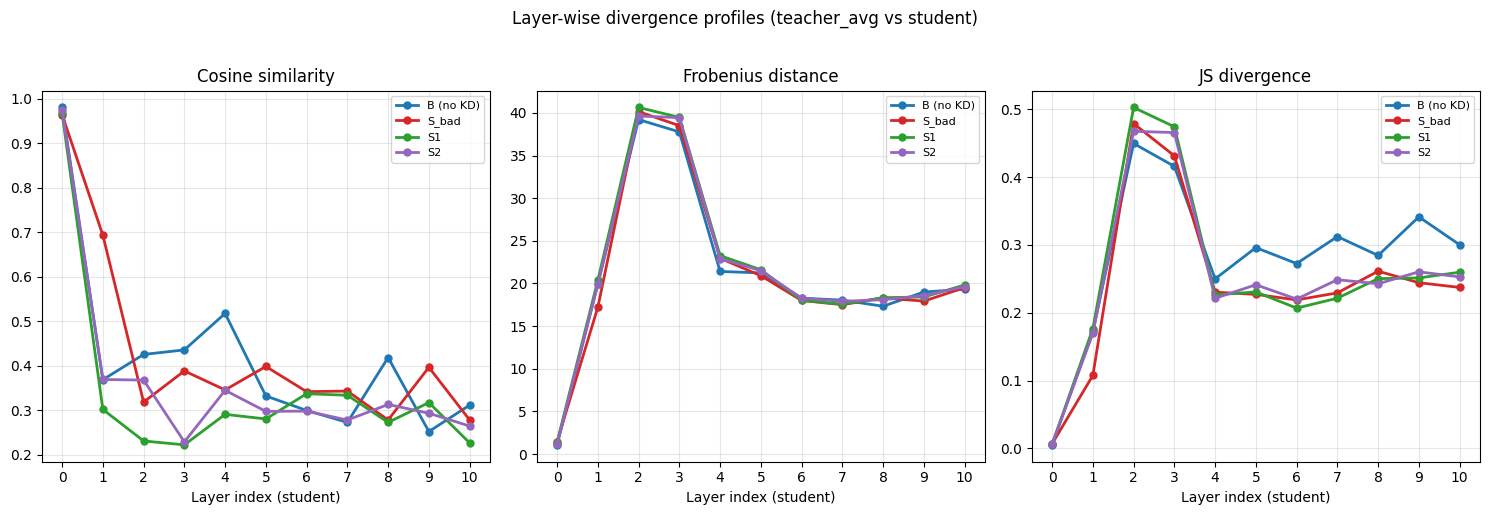

Saved: ../images/agnews_layer_divergence_profiles.png


In [67]:
import os; os.makedirs("../images", exist_ok=True)
# Layer-wise divergence: each student vs teacher_avg_attentions (per layer)
STUDENT_KEYS = ["baseline", "bad_student", "student", "student_local"]
MODEL_COLORS = {
    "baseline":      "tab:blue",
    "bad_student":   "tab:red",
    "student":       "tab:green",
    "student_local": "tab:purple",
}

layer_idx = list(range(11))

cosine_by_model    = {}
frobenius_by_model = {}
js_by_model        = {}

for name in STUDENT_KEYS:
    s_attns = model_attentions[name]
    cos_v, frob_v, js_v = [], [], []
    for k in range(11):
        t = teacher_avg_attentions[k]
        s = s_attns[k]
        cos_v.append(cosine_similarity_tensor(t, s).item())
        frob_v.append(frobenius_difference(t, s).item())
        js_v.append(js_divergence_attention(t, s).item())
    cosine_by_model[name]    = cos_v
    frobenius_by_model[name] = frob_v
    js_by_model[name]        = js_v

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (data, title) in zip(axes, [
    (cosine_by_model,    "Cosine similarity"),
    (frobenius_by_model, "Frobenius distance"),
    (js_by_model,        "JS divergence"),
]):
    for name in STUDENT_KEYS:
        ax.plot(layer_idx, data[name], label=MODEL_LABELS[name],
                color=MODEL_COLORS[name], marker="o", linewidth=2, markersize=5)
    ax.set_xlabel("Layer index (student)")
    ax.set_title(title)
    ax.set_xticks(layer_idx)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
plt.suptitle("Layer-wise divergence profiles (teacher_avg vs student)", y=1.02)
plt.tight_layout()
plt.savefig("../images/agnews_layer_divergence_profiles.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: ../images/agnews_layer_divergence_profiles.png")


# C. Per-head similarity heatmaps

In [68]:
# Compute per-head attention patterns (N=50, max_seq=128)
eval_prompts_50 = [build_prompt(t) for t in eval_texts[:50]]

head_patterns = {}
for name, model in MODELS.items():
    print(f"Head patterns for {MODEL_LABELS[name]}...")
    model.to(device)
    head_patterns[name] = compute_head_avg_patterns(
        model, eval_prompts_50, tokenizer, device, n=50, max_seq=128
    )
    model.cpu()
    torch.cuda.empty_cache()

print("Done. Shape:", head_patterns["teacher"].shape)


Head patterns for P (teacher)...
Head patterns for B (no KD)...
Head patterns for S_bad...
Head patterns for S1...
Head patterns for S2...
Done. Shape: torch.Size([22, 32, 128])


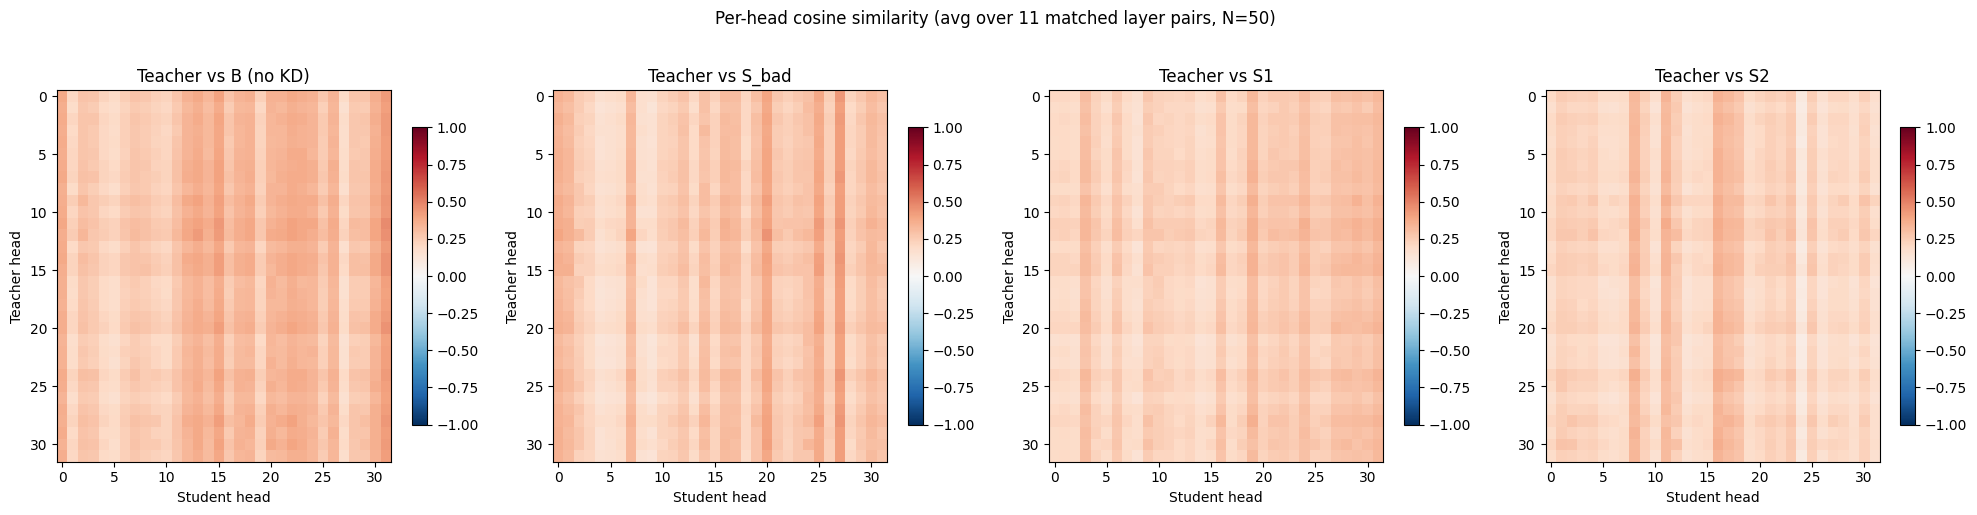

Saved: ../images/agnews_head_similarity_heatmap.png


In [69]:
import os; os.makedirs("../images", exist_ok=True)
# Per-head cosine-similarity heatmap: teacher vs each student
# 32x32 matrix averaged over 11 matched layer pairs
teacher_hp = head_patterns["teacher"]   # [22, n_heads, 128]
n_heads    = teacher_hp.shape[1]

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, name in zip(axes, STUDENT_KEYS):
    student_hp = head_patterns[name]    # [11, n_heads, 128]
    sim_sum = torch.zeros(n_heads, n_heads)
    for k in range(11):
        t_paired = (teacher_hp[2*k] + teacher_hp[2*k+1]) / 2
        s        = student_hp[k]
        t_norm   = t_paired / (t_paired.norm(dim=1, keepdim=True) + 1e-12)
        s_norm   = s        / (s.norm(dim=1, keepdim=True) + 1e-12)
        sim_sum += (t_norm @ s_norm.T)
    sim_avg = (sim_sum / 11).numpy()
    im = ax.imshow(sim_avg, vmin=-1, vmax=1, cmap="RdBu_r", aspect="auto")
    ax.set_title(f"Teacher vs {MODEL_LABELS[name]}")
    ax.set_xlabel("Student head")
    ax.set_ylabel("Teacher head")
    plt.colorbar(im, ax=ax, shrink=0.8)
plt.suptitle("Per-head cosine similarity (avg over 11 matched layer pairs, N=50)", y=1.02)
plt.tight_layout()
plt.savefig("../images/agnews_head_similarity_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: ../images/agnews_head_similarity_heatmap.png")


# D. Hidden states — Linear CKA

In [70]:
# Compute hidden states for all models (N=100, max_seq=512)
eval_prompts_100 = [build_prompt(t) for t in eval_texts[:100]]

hidden_states_all = {}
for name, model in MODELS.items():
    print(f"Hidden states for {MODEL_LABELS[name]}...")
    model.to(device)
    hidden_states_all[name] = compute_hidden_states(
        model, eval_prompts_100, tokenizer, device, n=100, max_seq=512
    )
    model.cpu()
    torch.cuda.empty_cache()

print("Shapes:", {k: tuple(v.shape) for k, v in hidden_states_all.items()})


Hidden states for P (teacher)...
Hidden states for B (no KD)...
Hidden states for S_bad...
Hidden states for S1...
Hidden states for S2...
Shapes: {'teacher': (23, 100, 2048), 'baseline': (12, 100, 2048), 'bad_student': (12, 100, 2048), 'student': (12, 100, 2048), 'student_local': (12, 100, 2048)}


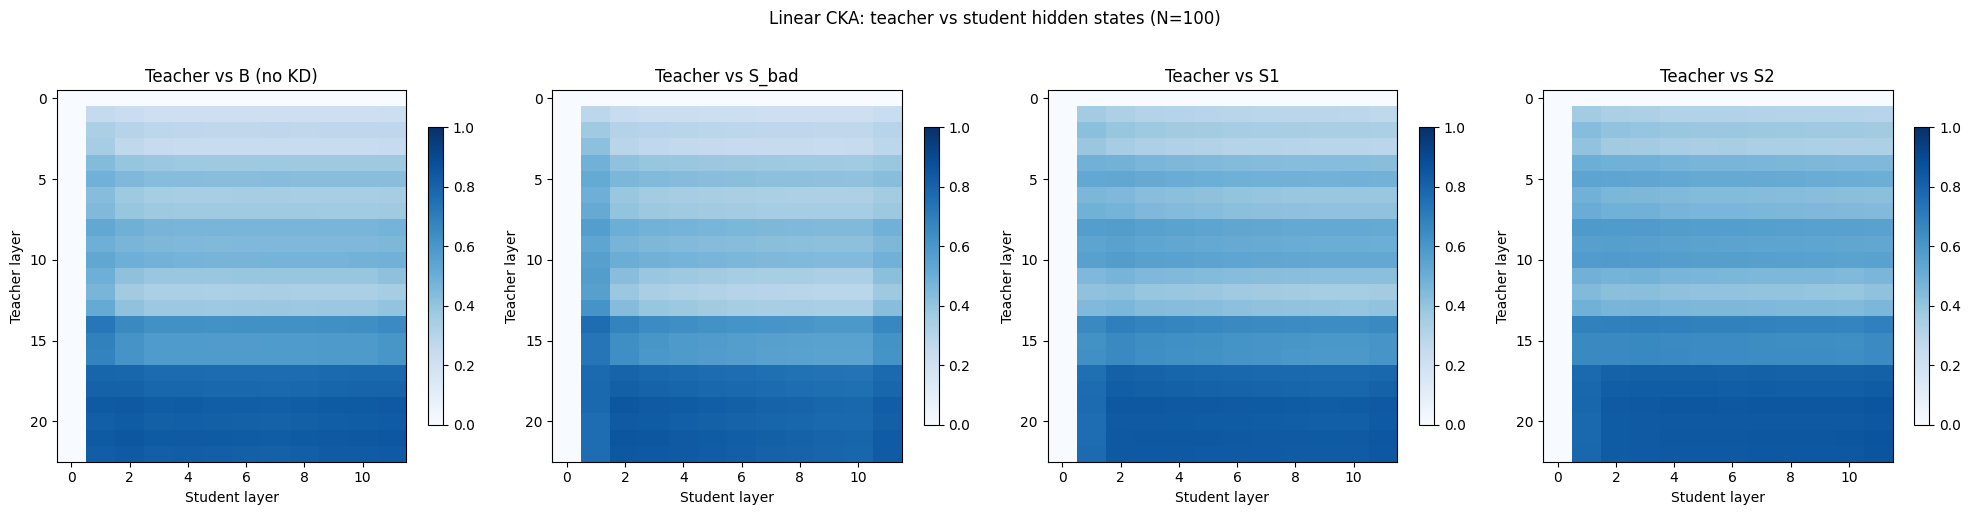

Saved: ../images/agnews_cka_heatmap.png


In [71]:
import os; os.makedirs("../images", exist_ok=True)
# Linear CKA heatmap: teacher layers vs student layers (N=100)
import numpy as np

teacher_hs = hidden_states_all["teacher"]  # [23, 100, 2048]

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, name in zip(axes, STUDENT_KEYS):
    student_hs = hidden_states_all[name]   # [12, 100, 2048]
    n_t = teacher_hs.shape[0]
    n_s = student_hs.shape[0]
    cka_mat = np.zeros((n_t, n_s))
    for i in range(n_t):
        for j in range(n_s):
            cka_mat[i, j] = linear_cka(teacher_hs[i], student_hs[j])
    im = ax.imshow(cka_mat, vmin=0, vmax=1, cmap="Blues", aspect="auto")
    ax.set_title(f"Teacher vs {MODEL_LABELS[name]}")
    ax.set_xlabel("Student layer")
    ax.set_ylabel("Teacher layer")
    plt.colorbar(im, ax=ax, shrink=0.8)
plt.suptitle("Linear CKA: teacher vs student hidden states (N=100)", y=1.02)
plt.tight_layout()
plt.savefig("../images/agnews_cka_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: ../images/agnews_cka_heatmap.png")
